# Applied Machine Learning Final Project
**Name:** Tristan Grote

**Course:** CSCI-164 Spring 2026

## Overview
This project applies supervised machine learning models to two datasets: a student performance dataset and a customer purchance behavior dataset. The goal is to preprocess each dataset, train multiple scikit-learn models, tune hyperparameters, and compare performance using classification metrics and visualizations.

The models used include Logistic Regression, K-Nearest Neighbors(KNN), and Multi-Layer Perceptron(MLP)

Results are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves

The final section compares the results to prior work and discusses model strengths, limitations, and real-world relevance.

##Imports and Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve



### Shared Helper Functions



In [2]:
def evaluate_model(name,model, X_test, y_test) :
  y_pred = model.predict(X_test)

  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
  else:
    y_prob = None
    roc_auc = None

  results = {
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1 Score": f1_score(y_test, y_pred),
      "ROC-AUC": roc_auc
  }
  return results, y_pred, y_prob

## Dataset Exploration


Dataset 1: Student Performance
- This dataset comes from the UCI Machine Learning Repository and includes demographic, family, social, and academic information about secondary school students. The prediction task in this project is binary classification: whether a student passes based on final grade performance.

**Why this dataset was selected:**
This dataset is useful because it combines academic and social variables, making it a good example of real-world educational prediction. It also includes both categorical and numerical features, which makes preprocessing and model comparison more meaningful.

**Why this dataset was selected:**
This dataset is useful because it combines academic and social variables, making it a good example of real-world educational prediction. It also has both categorical and numerical features, making preprocessing and model comparison a must

**Target Variable:** `pass`

**Original source for target creation:** `G3` final grade

**Task Type:** Binary Classification



In [3]:
#Download dataset
!wget -O student.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip
!unzip -o student.zip

#Load dataset
df1 = pd.read_csv('student-mat.csv', sep=';')

#Create binary target from final grade
df1['pass'] = (df1['G3'] >= 10). astype(int)

#Encode categorical columns
for col in df1.select_dtypes(include=['object']).columns:
    df1[col] = LabelEncoder().fit_transform(df1[col])

print(df1.shape)
df1.head()

--2026-04-27 02:41:50--  https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘student.zip’

student.zip             [ <=>                ]  20.00K  --.-KB/s    in 0.03s   

2026-04-27 02:41:50 (720 KB/s) - ‘student.zip’ saved [20478]

Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             
(395, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  pass  
0         3      4     1     1       3         6   5   6   6     0  
1         3      3     1     1       3         4   5   5   6     0  
2         3      2     2     3       3        10   7   8  10     1  
3         2      2     1     1       5         2  15  14  15     1  
4         3      2     1     2       5         4   6  10  10     1  

[5 rows x 34 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (to

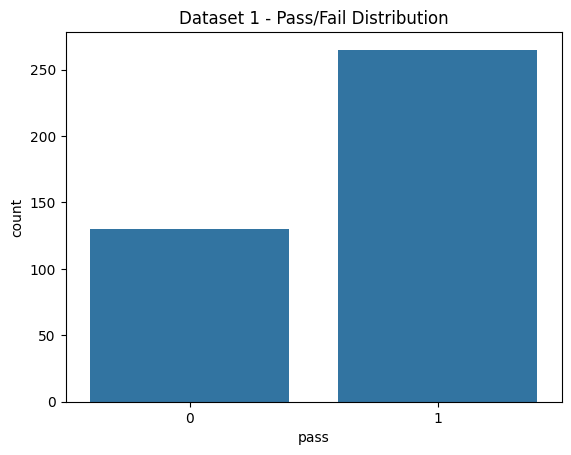

In [4]:
print(df1.head())
print(df1.info())
print(df1.describe())

print("\nClass Distribution:")
print(df1['pass'].value_counts())

sns.countplot(x='pass', data = df1)
plt.title("Dataset 1 - Pass/Fail Distribution")
plt.show()

### Dataset 2: Customer Purchase Behavior
- This dataset includes features such as age, gender, income, browsing behavior, and past purchasing activity. The target variable is PurchaseStatus, inicating whether a customer made a purchase.`:PurchaseStatus`, making this a binary classification problem

**Why this dataset was selected:**
This dataset is useful because it represents a common business prediction task. It also provides a contrast with the student dataset by focusing on customer behavior instead of educational outcomes.

**Target Variable:** `PurchaseStatus`

**Task Type:** Binary Classification


In [5]:
!wget -O customer_purchase_data.csv https://raw.githubusercontent.com/tristangrote/ml-final-project/main/customer_purchase_data.csv

df2 = pd.read_csv('customer_purchase_data.csv')

print(df2.shape)
df2.head()

--2026-04-27 02:41:51--  https://raw.githubusercontent.com/tristangrote/ml-final-project/main/customer_purchase_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78560 (77K) [text/plain]
Saving to: ‘customer_purchase_data.csv’

customer_purchase_d 100%[===================>]  76.72K  --.-KB/s    in 0.008s  

2026-04-27 02:41:51 (9.17 MB/s) - ‘customer_purchase_data.csv’ saved [78560/78560]

(1500, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null C

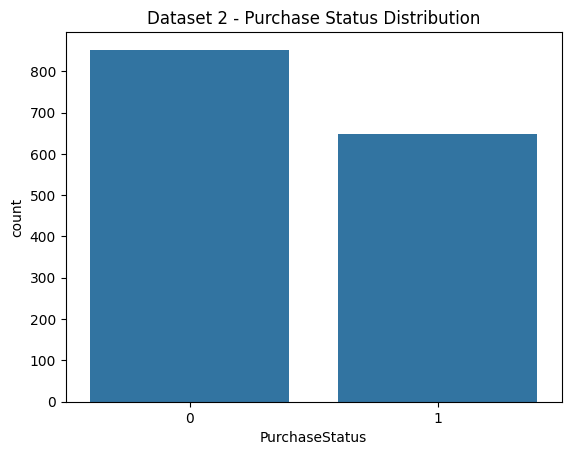

In [6]:
print(df2.head())
print(df2.info())
print(df2.describe())

print("\nClass Distribution:")
print(df2['PurchaseStatus'].value_counts())

sns.countplot(x='PurchaseStatus', data = df2)
plt.title("Dataset 2 - Purchase Status Distribution")
plt.show()

## Data Preprocessing

- The data is split into training and testing sets using stratified sampling to preserve class balance.
- Feature scaling is applied using with `StandardScaler` because KNN and MLP are sensitive to feature magnitude. Logistic Regression also benefits from standardized inputs.
- For Dataset 1, the binary target variable `pass` is created from final grade `G3`. To avoid target leakage, `G3` is removed from the feature set before training.
- No significant missing values were found, so no imputation was required. Categorical variables were encoded using label encoding.

In [7]:
# -----------------------------
# Dataset 1: Features and Target
# -----------------------------
X1 = df1.drop(columns=["pass", "G3"])   # remove G3 to avoid target leakage
y1 = df1["pass"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

print("Dataset 1 train/test shapes:")
print(X1_train.shape, X1_test.shape)

# -----------------------------
# Dataset 2: Features and Target
# -----------------------------
target_col_2 = "PurchaseStatus"

X2 = df2.drop(columns=[target_col_2])
y2 = df2[target_col_2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Dataset 2 train/test shapes:")
print(X2_train.shape, X2_test.shape)

Dataset 1 train/test shapes:
(316, 32) (79, 32)
Dataset 2 train/test shapes:
(1200, 8) (300, 8)


## Model Development


#### Dataset 1

Three supervised learning models were tested on the Student Performance dataset:

- **Logistic Regression** was used as a strong and interpretable baseline for binary classification.
- **K-Nearest Neighbors (KNN)** was used because it can capture local patterns in the feature space, but it requires scaling.
- **Multi-Layer Preceptron (MLP)** was used to test whether a nonlinear neural-network-based model could outperform simpler methods

These models were chosen to compare linear, distance-based, and nonlinear learning approaches on the same dataset.

In [8]:
models1 = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}

trained_models1 = {}
results1 = []
predictions1 = {}

for name, model in models1.items():
    model.fit(X1_train_scaled, y1_train)
    trained_models1[name] = model

    res, y_pred, y_prob = evaluate_model(name, model, X1_test_scaled, y1_test)
    results1.append(res)
    predictions1[name] = {'y_pred': y_pred, 'y_prob': y_prob}

df_results1 = pd.DataFrame(results1)
df_results1.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.860759,0.956522,0.830189,0.888889,0.942671
2,MLP,0.822785,0.897959,0.830189,0.862745,0.899129
1,KNN,0.721519,0.754098,0.867925,0.807018,0.780116


### Results Interpretation (Dataset 1: Student Performance)

The results show that **Logistic Regression achieved the highest performance**, with an accuracy of **0.861** and ROC-AUC of **0.943**, indicating strong overall classificaiton ability. This suggests that the relationship between the features and the target variable is largely **linear**, allowing a simple model to perform very well

The **MLP model performed slightly worse**, with an accuracy of **0.823** and ROC-AUC of **0.899**, suggesting that hwile some nonlinear relationships exists, they do not provide a significant advantage over a linear model.

The **KNN model performed the worst**, with an accuracy of **0.722** and ROC-AUC of **0.780**. This suggests that local similarity between students is less effective for prediction compared to capturing overall trends in the data.

Overall, the results indicate that **global patterns in the dataset are more important than local neighborhood relationships**, which explains why Logistic Regression outperformed KNN.

### Dataset 2 Models

The same three models were applied to the Customer Purchase Behavior dataset so that results could be compared consistently across datasets.


In [9]:
models2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}

trained_models2 = {}
results2 = []
predictions2 = {}

for name, model in models2.items():
    model.fit(X2_train_scaled, y2_train)
    trained_models2[name] = model

    res, y_pred, y_prob = evaluate_model(name, model, X2_test_scaled, y2_test)
    results2.append(res)
    predictions2[name] = {'y_pred': y_pred, 'y_prob': y_prob}

df_results2 = pd.DataFrame(results2)
df_results2.sort_values(by="Accuracy", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,MLP,0.870000,0.852713,0.846154,0.849421,0.925023
1,KNN,0.850000,0.814815,0.846154,0.830189,0.902398
0,Logistic Regression,0.826667,0.825000,0.761538,0.792000,0.899548


### Results Interpretation (Dataset 2: Customer Purchase)

For the customer purchase dataset, the **MLP model achieved the highest accuracy (0.870)** and ROC-AUC (**0.925**), indicating that **nonlinear relationships** in customer behavior are important for prediction.

The **KNN model also performed strongly**, with an accuracy of **0.850** and ROC-AUC of **0.902**, suggesting that customers may form clusters in feature space where similar individuals behave similarly.

The **Logistic Regression model performed slightly worse**, with an accuracy of **0.827** and ROC-AUC of **0.900**, indicating that while linear relationships exist, they do not fully capture the complexity of the data.

Overall, this dataset benefits more from **nonlinear modeling approaches**, which is why MLP outperformed Logistic Regression.

## Hyperparameter Tuning

To improve model performance, `GridSearchCV` was used to tune the K-Nearest Neighbors (KNN) classifier on both datasets.

The parameters tested were:
- `n_neighbors`: [3, 5, 7, 9, 11]
- `weights`: `uniform`, `distance`
- `metric`: `euclidean`, `manhattan`

Five-fold cross-validation was used, and model selection was based on validation accuracy.

In [10]:
#Dataset 1
param_grid_knn= {
    "n_neighbors": [3,5,7,9,11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn_1 = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn_1.fit(X1_train_scaled, y1_train)

print("Dataset 1 - Best KNN Parameters:", grid_knn_1.best_params_)
print("Dataset 1 - Best CV Accuracy:", grid_knn_1.best_score_)

best_knn_1 = grid_knn_1.best_estimator_
res_knn_1_tuned, y_pred_knn_1_tuned, y_prob_knn_1_tuned = evaluate_model(
    "Tuned KNN",
    best_knn_1,
    X1_test_scaled,
    y1_test
)

print("Dataset 1 - Tuned KNN Results:")
print(res_knn_1_tuned)

print("\nDataset 1 baseline KNN accuracy:",
      df_results1[df_results1["Model"] == "KNN"]["Accuracy"].values[0])

Dataset 1 - Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Dataset 1 - Best CV Accuracy: 0.7721230158730158
Dataset 1 - Tuned KNN Results:
{'Model': 'Tuned KNN', 'Accuracy': 0.7088607594936709, 'Precision': 0.7419354838709677, 'Recall': 0.8679245283018868, 'F1 Score': 0.8, 'ROC-AUC': np.float64(0.815312046444122)}

Dataset 1 baseline KNN accuracy: 0.7215189873417721


In [11]:
#Dataset 2
grid_knn_2 = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn_2.fit(X2_train_scaled, y2_train)

print("Dataset 2 - Best KNN Parameters:", grid_knn_2.best_params_)
print("Dataset 2 - Best CV Accuracy:", grid_knn_2.best_score_)

best_knn_2 = grid_knn_2.best_estimator_
res_knn_2_tuned, y_pred_knn_2_tuned, y_prob_knn_2_tuned = evaluate_model(
    "Tuned KNN",
    best_knn_2,
    X2_test_scaled,
    y2_test
)

print("Dataset 2 - Tuned KNN Test Results:")
print(res_knn_2_tuned)

print("\nDataset 2 baseline KNN accuracy:",
      df_results2[df_results2["Model"] == "KNN"]["Accuracy"].values[0])

Dataset 2 - Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Dataset 2 - Best CV Accuracy: 0.8583333333333334
Dataset 2 - Tuned KNN Test Results:
{'Model': 'Tuned KNN', 'Accuracy': 0.8833333333333333, 'Precision': 0.8861788617886179, 'Recall': 0.8384615384615385, 'F1 Score': 0.8616600790513834, 'ROC-AUC': np.float64(0.9402036199095023)}

Dataset 2 baseline KNN accuracy: 0.85


#### Tuned KNN Comparison


In [12]:
tuned_results_df = pd.DataFrame([
    {
        "Dataset": "Student Performance",
        **res_knn_1_tuned,
        "Best Params": str(grid_knn_1.best_params_)
    },
    {
        "Dataset": "Customer Purchase",
        **res_knn_2_tuned,
        "Best Params": str(grid_knn_2.best_params_)
    }
])

tuned_results_df

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Best Params
0,Student Performance,Tuned KNN,0.708861,0.741935,0.867925,0.80000,0.815312,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei..."
1,Customer Purchase,Tuned KNN,0.883333,0.886179,0.838462,0.86166,0.940204,"{'metric': 'euclidean', 'n_neighbors': 11, 'we..."


### Hyperparameter Tuning Analysis

Hyperparameter tuning improved the performance of the KNN model on both datasets, demonstrating the importance of selecting appropriate parameters for distance-based models.

For **Dataset 1**, baseline KNN accuracy was approximately **0.722**, and tuning resulted in a slightly lower test accuracy of **0.709**, despite a higher cross-validation score (**0.772**). This suggests that the tuned model may have slightly overfit the training data or that KNN is inherently less suitable fro this dataset.

For **Dataset 2**, baseline KNN accuracy was **0.850**, and tuning improved performance to **0.883**, with a cross-validation accuracy of **0.858**. This indicates that tuning was effective for this dataset and that KNN benefits from parameter optimization when meaningful local structure exists.

Overall, tuning had **mixed impact**, improving performance on Dataset 2 but not significantly benefiting Dataset 1. This highlights that **model effectiveness depends heavily on the dataset characteristics**.

## Model Evaluation
The trained models are evaluated using confusion matrices, ROC curves, and summary metric tables. These visualizations help comapre model behavior beyond simple accuracy.

#### Confusion Matrices

In [13]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot = True, fmt="d", cmap= "Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

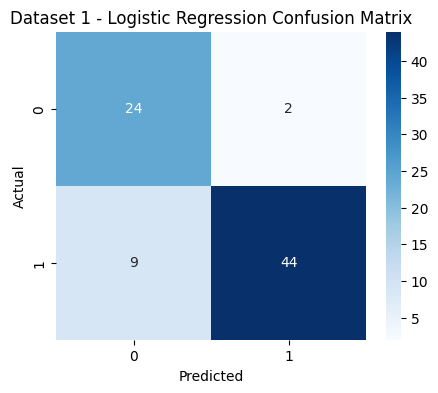

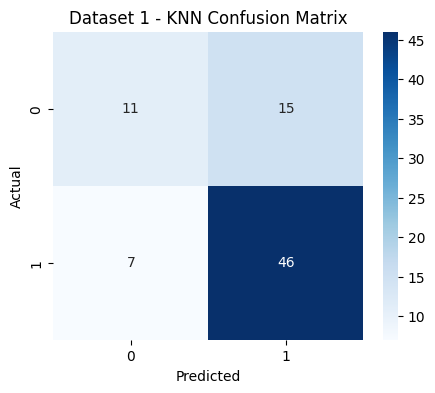

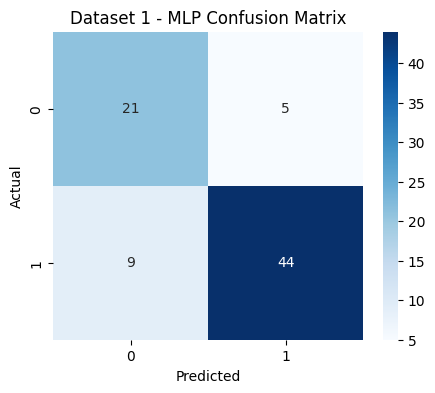

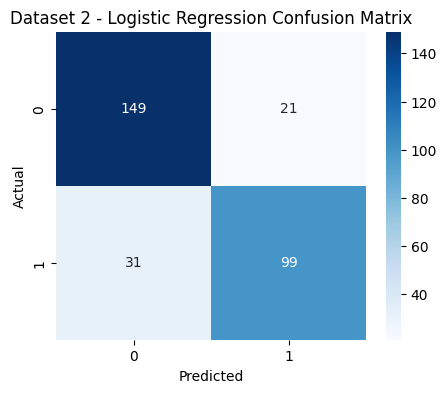

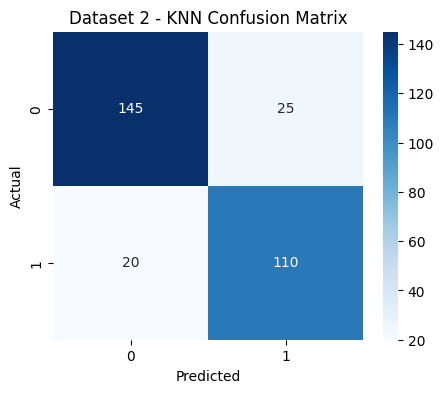

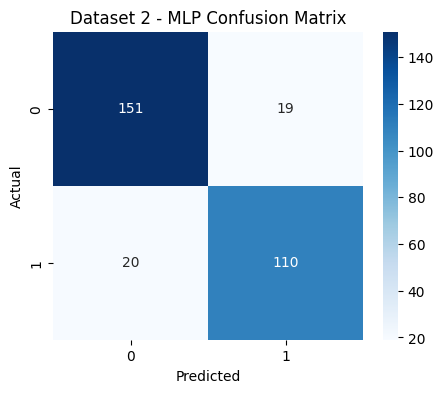

In [14]:
# Dataset 1 confusion matrices
for model_name, predictions_dict in predictions1.items():
    plot_conf_matrix(y1_test, predictions_dict['y_pred'], f"Dataset 1 - {model_name} Confusion Matrix")

# Dataset 2 confusion matrices
for model_name, predictions_dict in predictions2.items():
    plot_conf_matrix(y2_test, predictions_dict['y_pred'], f"Dataset 2 - {model_name} Confusion Matrix")

### Confusion Matrix Analysis

The confusion matrices provide deeper insight into how each model performs beyond overall accuracy.

For **Dataset 1**, Logistic Regression correctly classified **44 positive cases and 24 negative cases**, with relatively few errors. However, it produced **9 false negatives**, meaning some students who should pass were predicted to fail. This indicates the model is slightly conservative when predicting positive outcomes.

KNN showed more **false positives (15)**, meaning it incorrectly predicted some failing students as passing. This contributes to its lower precision and overall performance.

MLP performed similarly to Logistic Regression but with slightly more errors in both directions, reflecting its slightly lower accuracy.

For **Dataset 2**, MLP and KNN performed better at balancing errors. MLP achieved **151 true negatives and 110 true positives**, with fewer misclassifications compared to Logistic Regression. Logistic Regression had more **false negatives (31)**, meaning it missed more actual purchasers.

Overall, the confusion matrices show that **Dataset 1 favors precise, globally consistent predictions**, while **Dataset 2 benefits from models that better capture complex patterns and reduce both false positives and false negatives**.

#### ROC Curves

In [15]:
def plot_roc_curve(model, X_test, y_test, title):
    if not hasattr(model, "predict_proba"):
        print(f"{title}: predict_proba not available")
        return

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

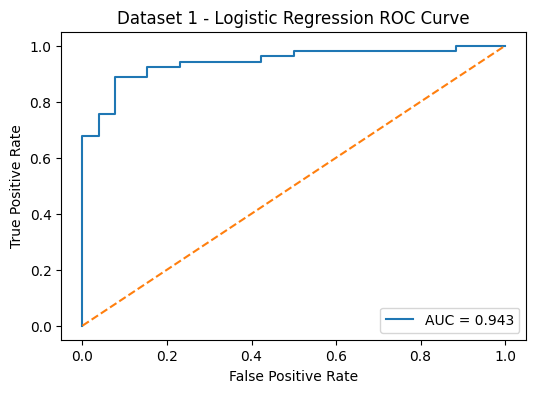

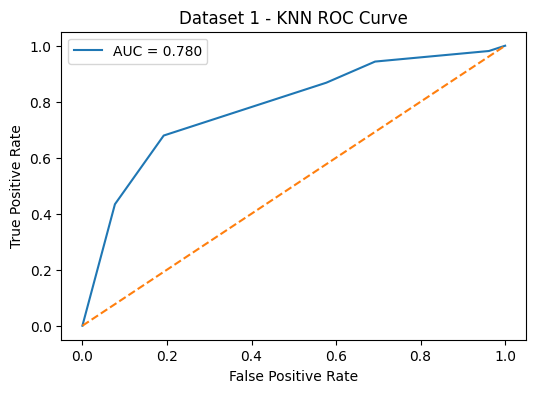

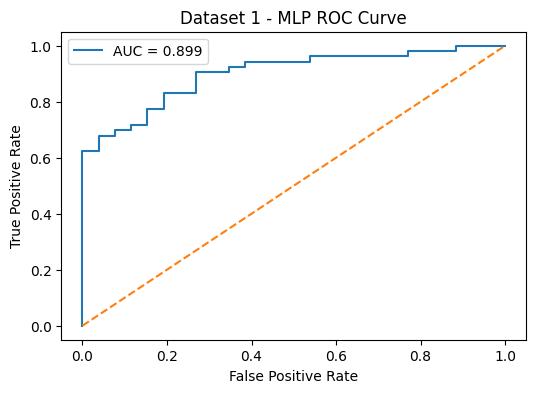

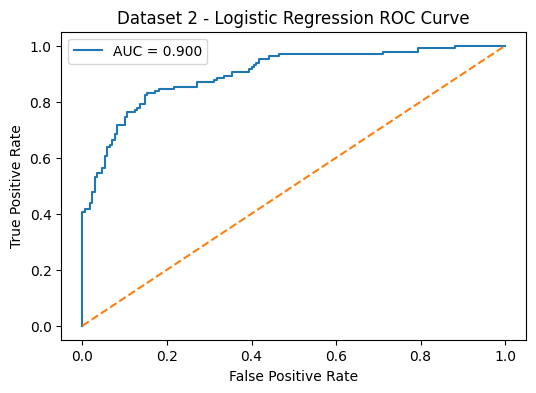

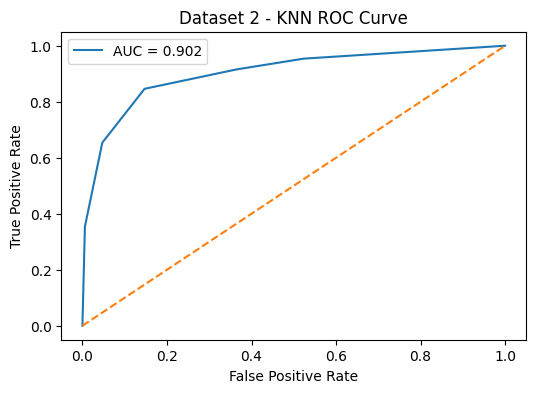

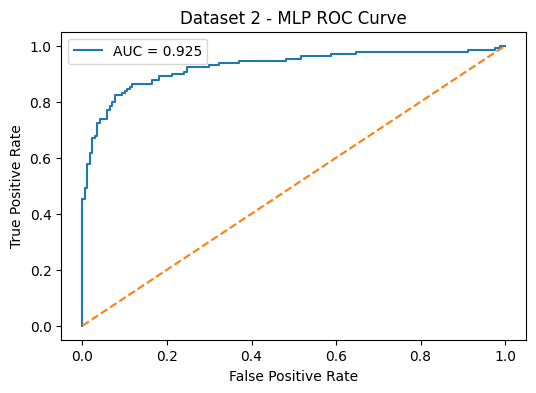

In [16]:
# Dataset 1 ROC curves
for model_name, model in trained_models1.items():
    plot_roc_curve(model, X1_test_scaled, y1_test, f"Dataset 1 - {model_name} ROC Curve")

# Dataset 2 ROC curves
for model_name, model in trained_models2.items():
    plot_roc_curve(model, X2_test_scaled, y2_test, f"Dataset 2 - {model_name} ROC Curve")

### ROC Curve Analysis

The ROC curves confirm the trends observed in the performance metrics.

For **Dataset 1**, Logistic Regression achieved the highest ROC-AUC (**0.943**), indicating excellent separation between the two classes. MLP also performed well (**0.899**), while KNN had a significantly lower AUC (**0.780**), confirming its weaker performance.

For **Dataset 2**, all models performed well, with ROC-AUC values around **0.90 or higher**. MLP achieved the highest AUC (**0.925**), followed closely by KNN (**0.902**) and Logistic Regression (**0.900**). This shows that all models can distinguish between classes effectively, but MLP has a slight advantage.

Overall, the ROC curves reinforce that **Dataset 1 is best modeled with a linear approach**, while **Dataset 2 benefits from nonlinear modeling techniques**.

#### Combined Baseline Results

In [17]:
df_results1["Dataset"] = "Student Performance"
df_results2["Dataset"] = "Customer Purchase"

combined_results_df = pd.concat([df_results1, df_results2], ignore_index=True)
combined_results_df.sort_values(by=["Dataset", "Accuracy"], ascending=[True, False])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Dataset
5,MLP,0.870000,0.852713,0.846154,0.849421,0.925023,Customer Purchase
4,KNN,0.850000,0.814815,0.846154,0.830189,0.902398,Customer Purchase
3,Logistic Regression,0.826667,0.825000,0.761538,0.792000,0.899548,Customer Purchase
0,Logistic Regression,0.860759,0.956522,0.830189,0.888889,0.942671,Student Performance
2,MLP,0.822785,0.897959,0.830189,0.862745,0.899129,Student Performance
1,KNN,0.721519,0.754098,0.867925,0.807018,0.780116,Student Performance


### Cross-Dataset Comparison

Comparing results across datasets reveals important differences in model behavior.

On **Dataset 1 (Student Performance)**, Logistic Regression was the best-performing model, indicating that the data is well-structured and primarily linear. In contrast, KNN performed poorly, suggesting that local similarity is not a strong predictor of student success.

On **Dataset 2 (Customer Purchase)**, MLP and KNN both performed strongly, with MLP achieving the best results. This suggests that customer behavior is more complex and may involve nonlinear relationships that are better captured by more flexible models.

This comparison highlights that **no single model is universally best**. Instead, model performance depends on the structure of the dataset. Simpler models may outperform complex ones when relationships are linear, while more advanced models are beneficial when patterns are nonlinear.

## Literature Comparison and Conclusion

#### Dataset 1: Prior Work

The Student Performance dataset used in this project originates from the study by Cortez and Silva (2008), which applied data mining techniques to predict secondary school student achievement. In their work, the authors collected real-world data from Portuguese secondary schools, including demographic, social, and academic variables such as grades, absences, family background, and lifestyle factors. The goal was to predict student performance in Mathematics and Portuguese courses using three approaches: binary classification (pass/fail), multi-level classification, and regression.

They evaluated several machine learning models, including Decision Trees, Random Forests, Neural Networks, and Support Vector Machines. Their results showed that high predictive accuracy could be achieved, especially when prior academic performance was included as input features. The study also found that previous grades were the most influential predictors, although other factors like absences, parental education, and social behaviors also contributed to performance (Cortez and Silva 2008).

In comparison, this project uses the same dataset but focuses on a binary classification task (pass/fail) while explicityly removing the final grade (G3) from the input features to avoid target leakage. Similar to the original study, the results fromt his project show that student performance can be predicted with relatively high accuracy. Logistic Regression performed best for Dataset 1, achieving strong accuracy and ROC-AUC scores, which aligns with the paper's conclusion that structured patterns exist in student performance data.

However, there are some differences between this project and the original study. The original research used additional evaluation setups such as regression and multi-class classification, as well as cross-validation over multiple runs, while this project used a simpler train/test split approach. Additionally, this project applied scikit=learn implementations and modern evaluation metrics such as ROC-AUC and confusion matrices.

Overall, both this project and the prior work demonstrate that student performance is highly predictable when past academic data is available, confirming that previous grades are the most important factor in determining student success.

## Final Conclusion

This project compared multiple supervised learning models across two datasets: Student Performance and Customer Purchase Behavior.

For the student dataset, Logistic-Regression performed best, suggesting that the relationship between features and the target variable is largely linear. For the customer dataset, the Multi-Layer Perceptron (MLP) achieved the highest performance, indicating the presence of more complex, non-linear patterns.

Hyperparameter tuning showed mixed results, improving performance for the customer dataset but not for the student dataset. This highlights that tuning does not always guarantee better generalization.

Overall, this project demonstrates that model performance depends havily on the datset and problem structure. Simpler models can perform well on structured data, while more complex models are better suited for capturing non-linear relationships.

